# Amazon Customer Sales & Product Analysis

## Introduction

This project performs an Exploratory Data Analysis (EDA) of Amazon customer order data to understand overall sales performance, product performance, pricing, discounts, and revenue contribution.

The analysis uses Python, primarily Pandas and NumPy, to transform the available order-level data into meaningful business insights. The dataset contains information related to orders, customers, products, categories, brands, quantities, unit prices, discounts, taxes, shipping costs, payment methods, order status, geographical locations, and sellers.

The primary objective of this analysis is to answer key business questions such as:

* What is the total revenue generated?
* How many orders were placed and how many units were sold?
* What is the average order value?
* How does revenue and order volume change over time?
* Which products generate the highest revenue?
* Which products have the highest sales volume?
* Which products appear in the highest number of orders?
* What are the highest- and lowest-priced products?
* Which products receive the highest and lowest discounts?
* How much revenue does each product contribute to overall sales?

The findings from this analysis can help identify high-performing products, understand sales patterns, evaluate pricing and discount strategies, and support data-driven business decisions.


1. Sales analysis
* Calculate:
1. Total revenue
2. Total orders
3. Total units
4. Average order value
5. Average product price
6. Monthly revenue
7. Monthly order volume

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Amazon_cleaned.csv")

In [3]:
df_copy = df.copy()

In [4]:
df_copy.head(5)

,OrderID,OrderDate,OrderYear,OrderMonth,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,...,GrossAmount,DiscountedAmount,NetAmount,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,2023,January,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,...,319.77,0.00,319.77,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,2023,December,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,...,251.37,12.57,238.80,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,2022,May,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,...,105.09,10.51,94.58,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,2023,July,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,...,167.90,25.18,142.72,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,2023,February,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,...,1031.28,257.82,773.46,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


* Total revenue
= Sum of (TotalAmount) for all orders

In [5]:
Total_revenue = df_copy["TotalAmount"].sum()
print("Total revenue is =",Total_revenue)

Total revenue is = 91825647.92


* Total orders = Count (OrderID)

In [6]:
Total_orders = df_copy["OrderID"].nunique()
print("Total orders =",Total_orders)

Total orders = 100000


* Total units = Sum of (Quantity)

In [7]:
Total_units = df_copy["Quantity"].sum()
print("Total unit sold =",Total_units)

Total unit sold = 300140


* Average Order Value (AOV) = Total Revenue / Total Orders

In [8]:
Total_revenue = df_copy["TotalAmount"].sum()
Total_orders = df_copy["OrderID"].nunique()
Average_order_value = (Total_revenue/Total_orders).round(3)
print("Average order value is =",Average_order_value)

Average order value is = 918.256


* Average product price = mean of (UnitPrice)

In [9]:
Average_product_price = (df_copy["UnitPrice"].mean()).round(3)
print("Average product price is =",Average_product_price)

Average product price is = 302.906


* Monthly revenue = TotalAmount / month

In [10]:
Monthly_revenue = (df_copy.groupby(["OrderYear","OrderMonth"])["TotalAmount"].sum())
print("Total monthly revenue is =",Monthly_revenue)

Total monthly revenue is = OrderYear  OrderMonth
2020       April         1588347.29
           August        1640874.93
           December      1577655.06
           February      1339388.21
           January       1637069.40
           July          1552981.94
           June          1500269.29
           March         1587125.66
           May           1533834.17
           November      1502232.24
           October       1515403.62
           September     1554682.21
2021       April         1470885.02
           August        1545324.30
           December      1520160.14
           February      1425365.99
           January       1575253.23
           July          1596668.40
           June          1593398.08
           March         1484165.89
           May           1571842.25
           November      1419480.77
           October       1511118.44
           September     1534912.30
2022       April         1515497.24
           August        1541701.50
           Dece

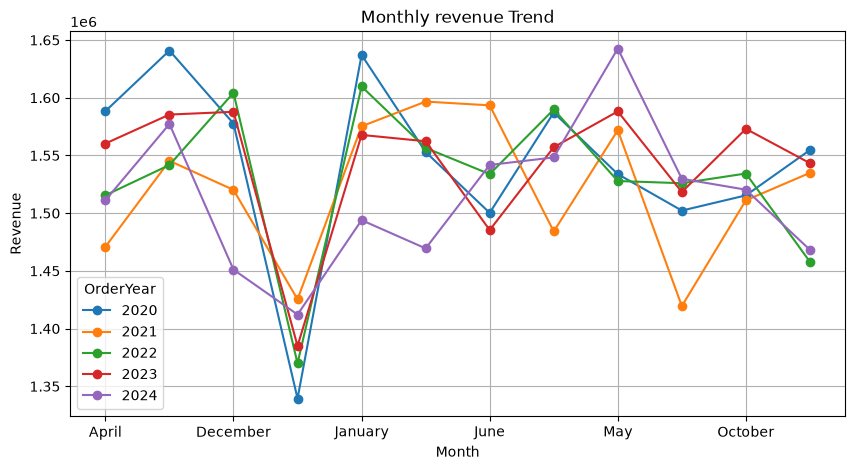

In [11]:
Monthly_revenue = (df_copy.groupby(["OrderYear","OrderMonth"])["TotalAmount"].sum()).unstack()
Monthly_revenue.T.plot(figsize=(10,5),marker = 'o')
plt.title("Monthly revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

* Monthly order volume = count the orderid per month

In [12]:
Monthly_order_volume = (df_copy.groupby(["OrderYear","OrderMonth"])["OrderID"].nunique())
print("Monthly order volume is =",Monthly_order_volume)

Monthly order volume is = OrderYear  OrderMonth
2020       April         1692
           August        1783
           December      1729
           February      1490
           January       1730
           July          1687
           June          1633
           March         1685
           May           1672
           November      1639
           October       1647
           September     1679
2021       April         1594
           August        1704
           December      1657
           February      1516
           January       1764
           July          1718
           June          1668
           March         1620
           May           1716
           November      1587
           October       1672
           September     1674
2022       April         1636
           August        1717
           December      1753
           February      1510
           January       1744
           July          1689
           June          1690
           March      

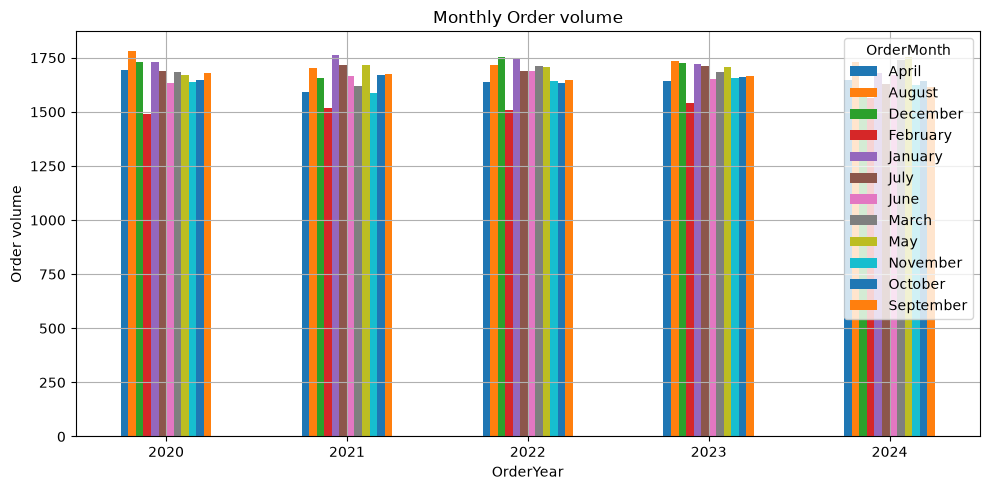

In [13]:
Monthly_orders = (df_copy.groupby(["OrderYear","OrderMonth"])["OrderID"].nunique()).unstack()
Monthly_orders.plot(kind="bar",figsize=(10,5))
plt.title("Monthly Order volume")
plt.xlabel("OrderYear")
plt.ylabel("Order volume")
plt.xticks(rotation = 360)
plt.grid(True)
plt.tight_layout()
plt.show()

2. Product analysis
* Find:
1. Top 10 products by revenue
2. Top 10 products by quantity
3. Top 10 products by orders
4. Highest & Lowest-priced products
5. Most-discounted product
6. Least-discounted product
7. Product revenue contribution

* Top 10 products by revenue

In [14]:
Top_products_rev = df_copy.groupby("ProductName")["TotalAmount"].sum().nlargest(10)
print("Top 10 products by revenue are =",Top_products_rev)

Top 10 products by revenue are = ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


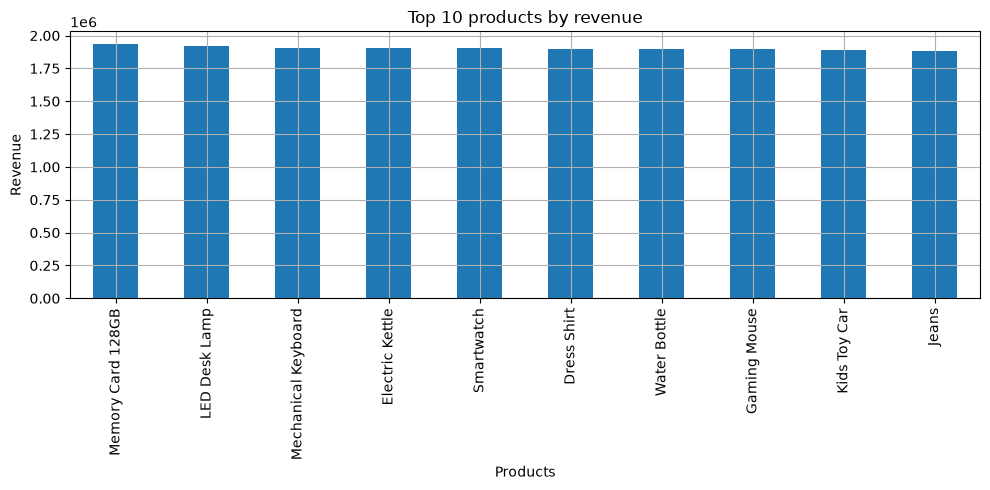

In [15]:
Top_products_rev = df_copy.groupby("ProductName")["TotalAmount"].sum().nlargest(10)
Top_products_rev.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 products by revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.xticks(rotation = 90)
plt.grid(True)
plt.tight_layout()
plt.show()

* Top 10 products by quantity

In [16]:
Top_products_qty = df_copy.groupby("ProductName")["Quantity"].sum().nlargest(10)
print("Top 10 products by quantity are =",Top_products_qty)

Top 10 products by quantity are = ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64


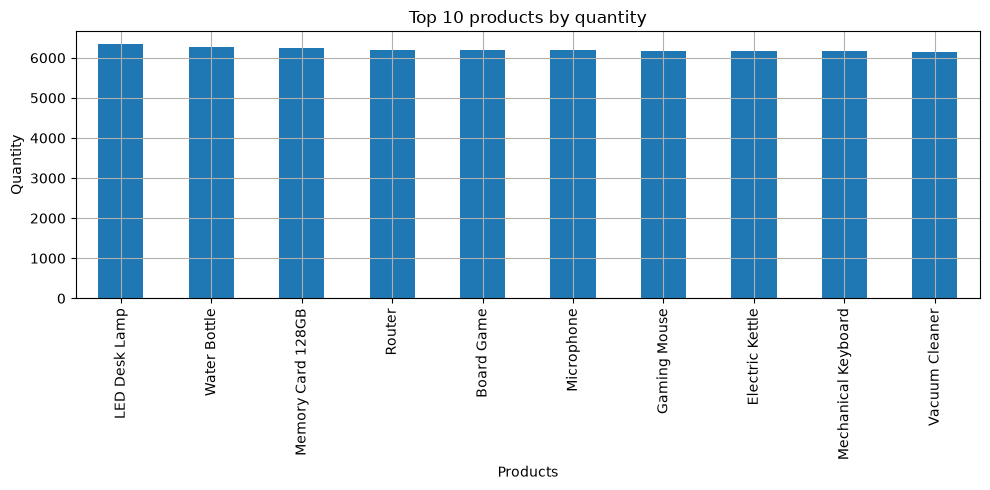

In [17]:
Top_products_qty = df_copy.groupby("ProductName")["Quantity"].sum().nlargest(10)
Top_products_qty.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 products by quantity")
plt.xlabel("Products")
plt.ylabel("Quantity")
plt.xticks(rotation = 90)
plt.grid(True)
plt.tight_layout()
plt.show()

* Top 10 products by order

In [18]:
Top_products_ord = df_copy.groupby("ProductName")["OrderID"].nunique().nlargest(10)
print("Top 10 products by order are =",Top_products_ord)

Top 10 products by order are = ProductName
LED Desk Lamp          2098
Water Bottle           2088
Cookware Set           2058
Electric Kettle        2054
Router                 2054
Yoga Mat               2041
Board Game             2039
Memory Card 128GB      2039
Smart Light Bulb       2036
Mechanical Keyboard    2034
Name: OrderID, dtype: int64


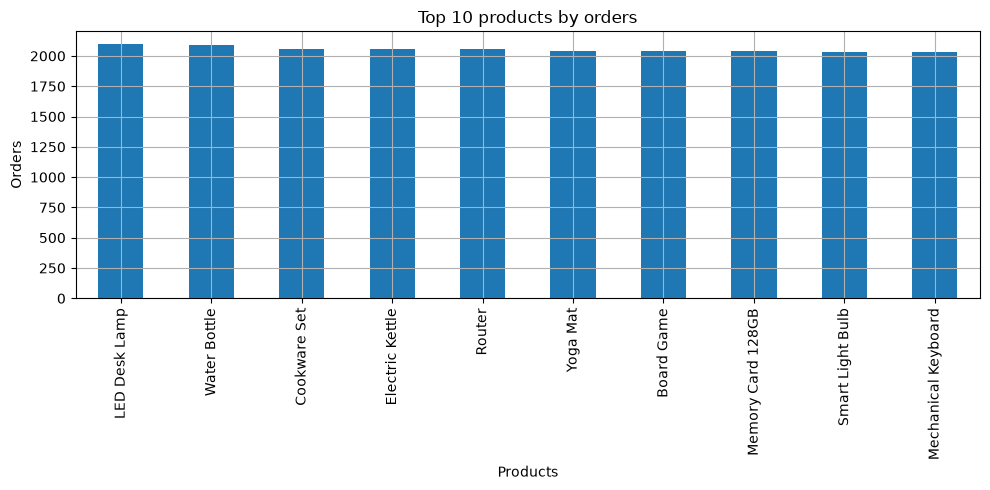

In [19]:
Top_products_ord = df_copy.groupby("ProductName")["OrderID"].nunique().nlargest(10)
Top_products_ord.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 products by orders")
plt.xlabel("Products")
plt.ylabel("Orders")
plt.xticks(rotation = 90)
plt.grid(True)
plt.tight_layout()
plt.show()

* Highest & Lowest peiced Products

In [20]:
Product_price = (
    df_copy.groupby("ProductName")["UnitPrice"]
    .max()
    .sort_values(ascending=False)
)

Highest_priced = Product_price.head(1)
Lowest_priced = Product_price.tail(1)

print("Highest priced product:")
print(Highest_priced)

print("\nLowest priced product:")
print(Lowest_priced)

Highest priced product:
ProductName
Desk Plant    599.99
Name: UnitPrice, dtype: float64

Lowest priced product:
ProductName
Wireless Charger    598.68
Name: UnitPrice, dtype: float64


* Most Discounted product

In [21]:
Most_discounted_product = df_copy.nlargest(1,"Discount")[["ProductName","Discount"]]
print("Most discounted product is =",Most_discounted_product.to_string(index=False))

Most discounted product is =      ProductName  Discount
Novel Bestseller       0.3


* Least Discounted Product

In [22]:
Least_discounted_product = df_copy.nsmallest(1,"Discount")[["ProductName","Discount"]]
print("Least Discounted product is =",Least_discounted_product.to_string(index=False))

Least Discounted product is = ProductName  Discount
 Drone Mini       0.0


* Product revenue contribution = (Product Revenue/ Total Revenue)*100

In [23]:
Product_revenue = df_copy.groupby("ProductName")["TotalAmount"].sum()
Product_revenue_contribution = (Product_revenue/Product_revenue.sum()*100).round(2).sort_values(ascending=False)
print("Product wise revenue contributions are =",Product_revenue_contribution.nlargest(10))

Product wise revenue contributions are = ProductName
Memory Card 128GB      2.11
LED Desk Lamp          2.09
Electric Kettle        2.08
Mechanical Keyboard    2.08
Smartwatch             2.07
Dress Shirt            2.07
Gaming Mouse           2.06
Water Bottle           2.06
Kids Toy Car           2.06
Jeans                  2.05
Name: TotalAmount, dtype: float64


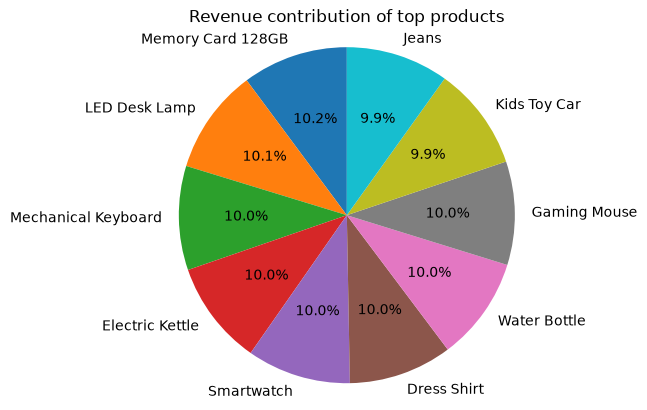

In [24]:
Product_revenue = df_copy.groupby("ProductName")["TotalAmount"].sum()
Product_revenue_contribution = (Product_revenue/Product_revenue.sum()*100).round(2).sort_values(ascending=False).nlargest(10)
plt.Figure(figsize=(10,8))
plt.pie(Top_products_rev,labels=Top_products_rev.index,autopct="%1.1f%%",startangle=90)
plt.title("Revenue contribution of top products")
plt.axis("equal")
plt.show()

# Conclusion

* **Overall Sales Performance:** The analysis covers **100,000 orders** and **300,140 units sold**, generating total revenue of approximately **91.83 million**.

* **Average Order Value:** The calculated Average Order Value (AOV) is approximately **918.26**, meaning each order generated around 918.26 in revenue on average.

* **Average Product Price:** The average product price in the dataset is approximately **302.91**.

* **Sales Over Time:** Monthly revenue and order volume were analyzed separately for each year from **2020 to 2024**, allowing yearly and monthly sales patterns to be compared without combining the same months across different years.

* **Monthly Revenue Pattern:** Revenue fluctuates across months and years, with monthly revenue generally remaining within a relatively consistent range rather than showing extreme variation.

* **Monthly Order Volume:** Order volume also varies across different months and years, with the analysis using unique Order IDs to measure monthly order activity.

* **Top Revenue-Generating Product:** **Memory Card 128GB** generated the highest revenue among the products analyzed, with approximately **1.94 million** in revenue.

* **Strong Product Performance:** **LED Desk Lamp** generated approximately **1.92 million** in revenue and is among the leading products in the revenue analysis.

* **Product Performance Comparison:** The top 10 products by revenue show relatively similar revenue levels, suggesting that revenue is distributed across several high-performing products rather than being concentrated in one product.

* **Business Insight:** The identified high-performing products can be considered for inventory planning, promotional campaigns, and product-prioritization strategies.

* **Overall Finding:** The analysis demonstrates how Python can be used to evaluate sales KPIs, identify monthly sales patterns, compare product performance, and convert transactional data into meaningful business insights.

* **Future Analysis:** Further analysis can focus on **customer behavior, category performance, brand performance, geographical sales, payment methods, order status, seller performance, and the relationship between discounts and revenue** to develop a more comprehensive understanding of the business.
